In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (60000, 28, 28)
Testing data: (10000, 28, 28)


In [ ]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (60000, 28, 28, 1)
Testing data: (10000, 28, 28, 1)


In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - accuracy: 0.9512 - loss: 0.1625 - val_accuracy: 0.9842 - val_loss: 0.0593
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9833 - loss: 0.0538 - val_accuracy: 0.9880 - val_loss: 0.0504
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9890 - loss: 0.0346 - val_accuracy: 0.9855 - val_loss: 0.0627
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 25ms/step - accuracy: 0.9929 - loss: 0.0228 - val_accuracy: 0.9855 - val_loss: 0.0538
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 24ms/step - accuracy: 0.9949 - loss: 0.0160 - val_accuracy: 0.9882 - val_loss: 0.0548


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9869 - loss: 0.0429
Test Accuracy: 0.9868999719619751
Test Accuracy (%): 98.68999719619751


In [ ]:
predictions = model.predict(X_test)

print("Predictions generated successfully!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Predictions generated successfully!


In [ ]:
import numpy as np

predicted_labels = np.argmax(predictions, axis=1)

print("First 10 predicted digits:", predicted_labels[:10])
print("First 10 actual digits:", y_test[:10])

First 10 predicted digits: [7 2 1 0 4 1 4 9 5 9]
First 10 actual digits: [7 2 1 0 4 1 4 9 5 9]


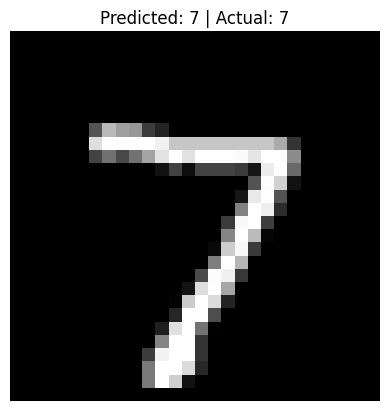

In [ ]:

import matplotlib.pyplot as plt

index = 0

plt.imshow(X_test[index].reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted_labels[index]} | Actual: {y_test[index]}")
plt.axis('off')
plt.show()

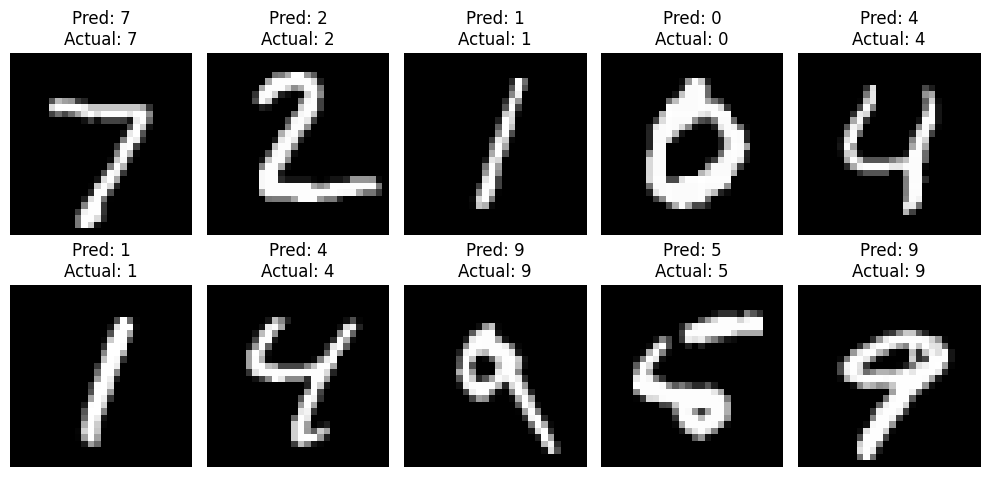

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}\nActual: {y_test[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

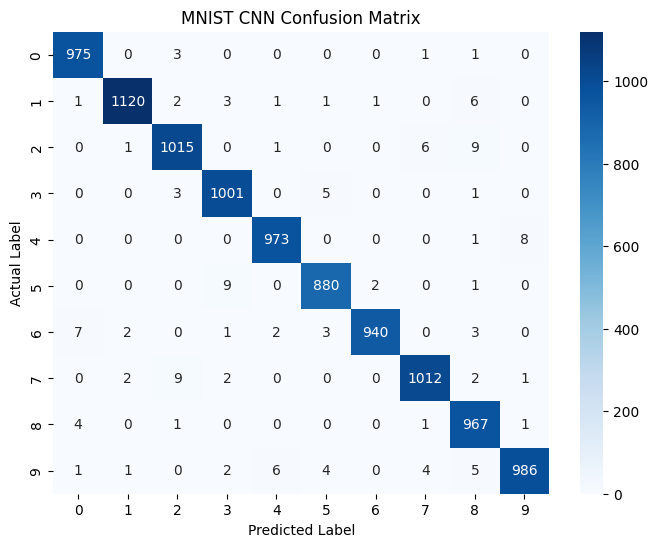

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("MNIST CNN Confusion Matrix")
plt.show()

## Task 3: Handwritten Character Recognition

### Project Summary
A Convolutional Neural Network (CNN) was developed to recognize handwritten digits using the MNIST dataset.

### Results
- Training Dataset: 60,000 images
- Testing Dataset: 10,000 images
- Image Size: 28 × 28 pixels
- Model: Convolutional Neural Network (CNN)
- Test Accuracy: 98.69%
- Prediction Visualization: Completed
- Confusion Matrix: Completed

### Conclusion
The CNN model successfully recognized handwritten digits from the MNIST dataset with a test accuracy of 98.69%.